<a href="https://colab.research.google.com/github/100522155/egci463/blob/main/Week3/Reading_digit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd
import numpy as np
import io

#Read digit from digit.csv
from google.colab import files
uploaded = files.upload()



Saving digit.csv to digit (1).csv


In [2]:
import pandas as pd
df = pd.read_csv(io.BytesIO(uploaded["digit.csv"]),header=None)

In [43]:
df


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


Show First digit

In [44]:
df.iloc[:,-1]

,784
0,0
1,0
2,0
3,0
4,0
...,...
495,9
496,9
497,9
498,9


In [45]:
print(np.reshape(np.array(df.iloc[0,:-1]),[28,28]))

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  51 159 253
  159  50   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  48 238 252 252
  252 237   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  54 227 253 252 239
  233 252  57   6   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  10  60 224 252 253 252 202
   84 252 253 122   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 163 252 252 252 25

In [46]:
import matplotlib.pyplot as plt


Reshape 500x784 --> 10 x 50 x 784
                   digit x Number    x pixel

In [47]:
digit =np.reshape(np.array(df.iloc[:,:-1]),[10,50,784])

Visualized a digit



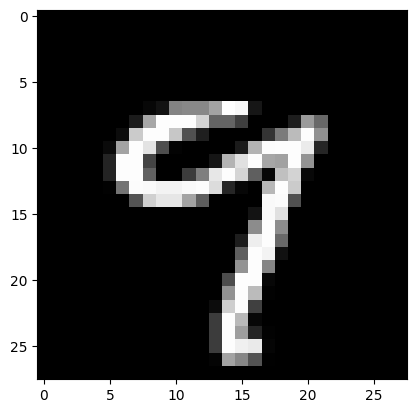

In [48]:
plt.imshow(np.reshape(digit[9,15,:],[28,28]),cmap='gray')
plt.show()

Try Visualize one of digit 3

In [9]:
print(digit[0,:,:].shape)

(50, 784)


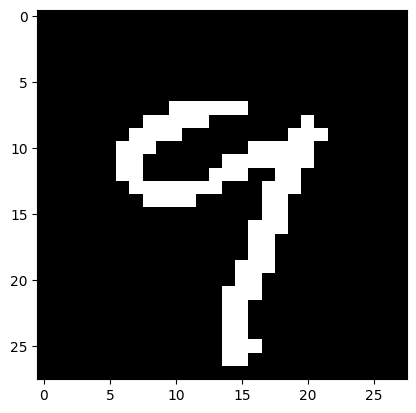

In [49]:
#show binary
bin_digit=1*(digit>128)
plt.imshow(np.reshape(bin_digit[9,15,:],[28,28]),cmap='gray')
plt.show()

# Create train data (80%/20%)

In [54]:
from sklearn.model_selection import train_test_split

x = df.iloc[:100, :-1].values #ignore the digit number column
y = df.iloc[:100, -1].values #digit label

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

train0 =   1*(X_train[y_train==0] > 128)
train1 =   1*(X_train[y_train==1] > 128)
test0,  test1  = 1*(X_test[y_test==0] > 128),  1*(X_test[y_test==1] > 128)

numbers = np.stack([train0.mean(axis=0), train1.mean(axis=0)])  # numbers[0]=P(D|0), numbers[1]=P(D|1)

print(numbers.shape)


(2, 784)


In [ ]:
#p=(0|D) = p(D|0) P(0)/p(D)
#p=(1|D) = p(D|1) P(1)/p(D)


#p(D)=p(D|0) P(0)+p(D|1) P(1)+p(D|2) P(2).....+p(D|10) P(10)


In [ ]:
print(train0.shape) #80% of randomly selected digit 0
print(test0.shape)  #20% of the rest -->test

(40, 784)
(10, 784)


In [ ]:
print(numbers[0])


[0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.025 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.125 0.25  0.2   0.25  0.3   0.325 0.25  0.075
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.025 0.075 0.1   0.25  0.375 0.575 0.65  0.725
 0.725 0.675 0.5   0.35  0.175 0.05  0.    0.    0.    0.    0.    0.
 0.    0.    0

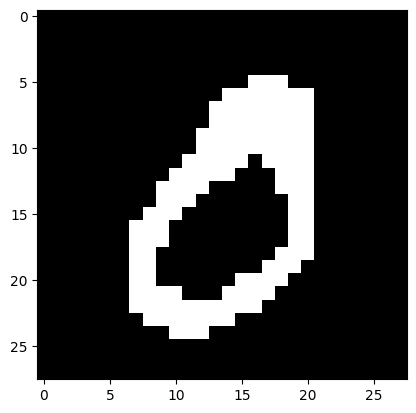

In [ ]:
plt.imshow(np.reshape(train0[10],[28,28]),cmap='gray')


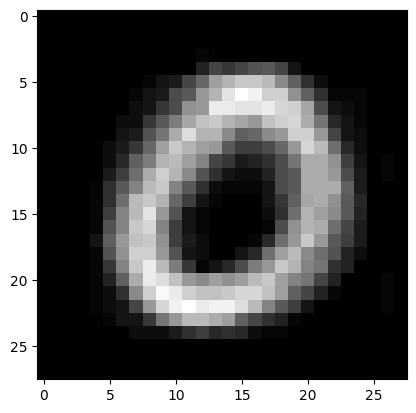

In [ ]:
plt.imshow(np.reshape(numbers[0],[28,28]),cmap='gray')


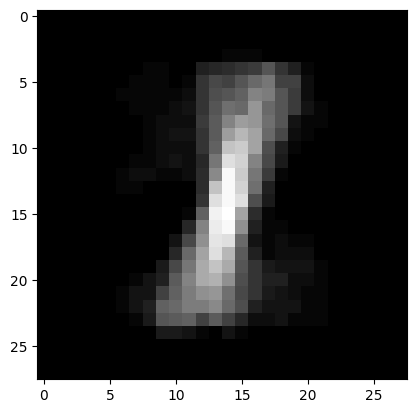

In [ ]:
plt.imshow(np.reshape(numbers[1],[28,28]),cmap='gray')


In [90]:
print(np.reshape(numbers[1],[28,28]))


[[0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.025 0.025 0.025 0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.025 0.025 0.    0.
  0.125 0.15  0.175 0.2   0.225 0.325 0.2   0.125 0.025 0.    0.    0.
  0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.025 0.025 0.025 0.    0.025
  0.2   0.275 0.25  0.325 0.4   0.45  0.25  0.25  0.05  0.    0.    0.
  0.    0.

In [91]:
(1-test0)*(1-numbers[0])


array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]])

In [92]:
# p(0|number) = p(digit|0) p(0)
p0 = np.prod(test0*numbers[0]+(1-test0)*(1-numbers[0]),axis=1)*0.5 # p(digit|0) p(0)
p1 = np.prod(test0*numbers[1]+(1-test0)*(1-numbers[1]),axis=1)*0.5 # p(digit|1) p(1)

prob0=p0/(p0+p1)
prob1=p1/(p0+p1)


/tmp/ipykernel_1065/2832603600.py:5: RuntimeWarning: invalid value encountered in divide
  prob0=p0/(p0+p1)
/tmp/ipykernel_1065/2832603600.py:6: RuntimeWarning: invalid value encountered in divide
  prob1=p1/(p0+p1)


In [93]:
print(np.array([prob0 ,prob1]).T)


[[nan nan]
 [ 1.  0.]
 [nan nan]
 [ 1.  0.]
 [nan nan]
 [nan nan]
 [ 1.  0.]
 [nan nan]
 [ 1.  0.]
 [nan nan]]


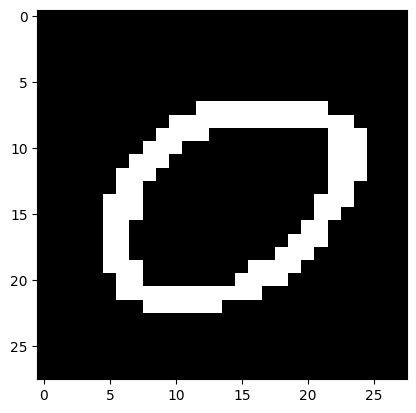

In [94]:
plt.imshow(np.reshape(test0[3],[28,28]),cmap='gray')


In [ ]:
p0 = np.prod(test1*numbers[0]+(1-test1)*(1-numbers[0]),axis=1)*.5 # p(digit|0) p(0)
p1 = np.prod(test1*numbers[1]+(1-test1)*(1-numbers[1]),axis=1)*.5 # p(digit|1) p(1)

prob0=p0/(p0+p1)
prob1=p1/(p0+p1)


/tmp/ipykernel_4369/2469727410.py:4: RuntimeWarning: invalid value encountered in divide
  prob0=p0/(p0+p1)
/tmp/ipykernel_4369/2469727410.py:5: RuntimeWarning: invalid value encountered in divide
  prob1=p1/(p0+p1)


In [ ]:
print(np.array([prob0 ,prob1]).T)

[[ 0.  1.]
 [nan nan]
 [ 0.  1.]
 [ 0.  1.]
 [ 0.  1.]
 [ 0.  1.]
 [ 0.  1.]
 [ 0.  1.]
 [nan nan]
 [nan nan]]


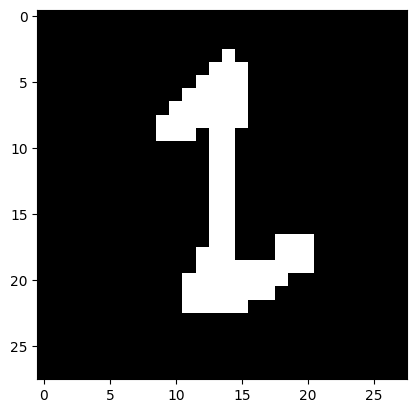

In [ ]:
plt.imshow(np.reshape(test1[7],[28,28]),cmap='gray')


# Compare to train Data

In [82]:
# p(0|number) = p(digit|0) p(0) /   (p(0|digit) p(0)+ p(1|digit) p(1))
p0 = np.prod(train0*numbers[0]+(1-train0)*(1-numbers[0]),axis=1)*.5 # p(digit|0) p(0)
p1 = np.prod(train0*numbers[1]+(1-train0)*(1-numbers[1]),axis=1)*.5 # p(digit|1) p(1)

prob0=p0/(p0+p1)
prob1=p1/(p0+p1)
print(np.array([prob0 ,prob1]).T)

[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [81]:
p0 = np.prod(train1*numbers[0]+(1-train1)*(1-numbers[0]),axis=1)*.5 # p(digit|0) p(0)
p1 = np.prod(train1*numbers[1]+(1-train1)*(1-numbers[1]),axis=1)*.5 # p(digit|1) p(1)

prob0=p0/(p0+p1)
prob1=p1/(p0+p1)
np.set_printoptions(precision=3,suppress=True)
print(np.array([prob0 ,prob1]).T)

[[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]


#Discussion ? Why 'Nan' Value-->What are they coming from?

The model estimates P(pixel = 1 | digit) as the average of that pixel over the training images. If a pixel was never active in any training image of a digit, its probability is exactly 0 (and exactly 1 if it was always on).
Naive Bayes multiplies the probabilities of all 784 pixels. If a test image has ink in a pixel that a digit never had during training, that single factor is 0, so P(image | digit) = 0 for that digit.
When the image is "impossible" for all digits, every numerator and the denominator are 0, so the result is 0/0 = NaN. In the log version, log(0) = −∞ and −∞ · 0 produces NaN as well
Also multiplying 784 numbers smaller than 1 can produce values too small for floating point, which get rounded to 0 and cause the same problem.

#Try with more/different digits

> Add blockquote



In [11]:
#Selected digits
selected_digits = [3, 4, 8]

In [100]:
df_filtered = df[df.iloc[:, -1].isin(selected_digits)] #3,4 and 8 photos estracted with


In [99]:
from sklearn.model_selection import train_test_split
X = df_filtered.iloc[:, :-1].values  # 784 pixels
y2 = df_filtered.iloc[:, -1].values   # etiquetes
print(X.shape)
print(y2)

X_train, X_test, y_train, y_test = train_test_split(X, y2, test_size=0.2, stratify=y2, random_state=42)

train3 =   1*(X_train[y_train==3] > 128)
train4 =   1*(X_train[y_train==4] > 128)
train8 =   1*(X_train[y_train==8] > 128)
test3,  test4, test8  = 1*(X_test[y_test==3] > 128),  1*(X_test[y_test==4] > 128), 1*(X_test[y_test==8] > 128)

(150, 784)
[3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 8 8 8 8 8 8 8 8 8 8 8
 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8
 8 8]


In [97]:
mapas_probabilidad = {}

mapas_probabilidad[3] = train3.mean(axis=0)
mapas_probabilidad[4] = train4.mean(axis=0)
mapas_probabilidad[8] = train8.mean(axis=0)

print( list(mapas_probabilidad.keys()))

[3, 4, 8]


In [78]:
print(train3.shape)
print(test3.shape)
print()
print(train4.shape)
print(test4.shape)
print()
print(train8.shape)
print(test8.shape)

(40, 784)
(10, 784)

(40, 784)
(10, 784)

(40, 784)
(10, 784)


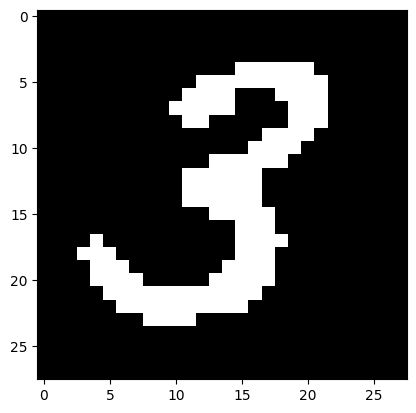

In [109]:
plt.imshow(np.reshape(train3[2],[28,28]),cmap='gray')

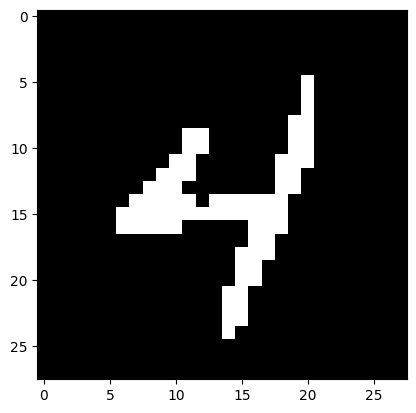

In [110]:
plt.imshow(np.reshape(train4[2],[28,28]),cmap='gray')

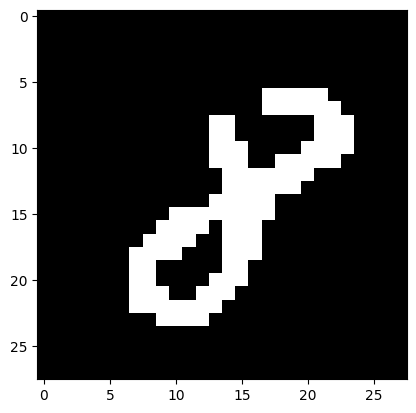

In [111]:
plt.imshow(np.reshape(train8[2],[28,28]),cmap='gray')

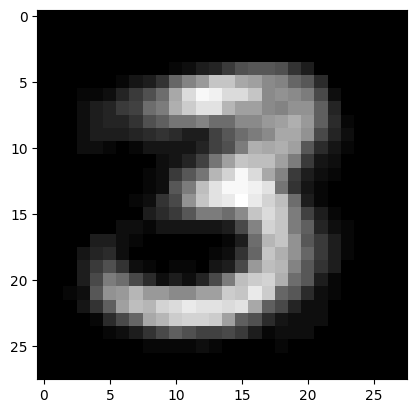

In [60]:
plt.imshow(np.reshape(mapas_probabilidad[3],[28,28]),cmap='gray')

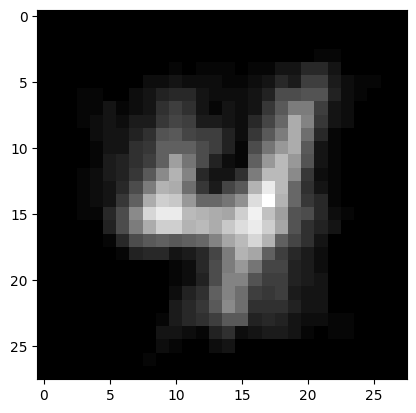

In [61]:
plt.imshow(np.reshape(mapas_probabilidad[4],[28,28]),cmap='gray')

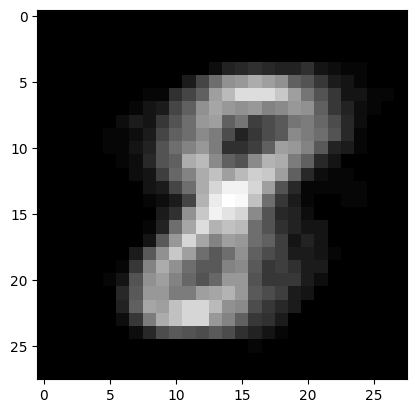

In [62]:
plt.imshow(np.reshape(mapas_probabilidad[8],[28,28]),cmap='gray')

In [114]:
p3 = np.prod(test3*mapas_probabilidad[3]+(1-test3)*(1-mapas_probabilidad[3]),axis=1)*.5 # p(digit|3) p(3)
p4 = np.prod(test3*mapas_probabilidad[4]+(1-test3)*(1-mapas_probabilidad[4]),axis=1)*.5 # p(digit|4) p(4)
p8 = np.prod(test3*mapas_probabilidad[8]+(1-test3)*(1-mapas_probabilidad[8]),axis=1)*.5 # p(digit|8) p(8)

total = p3 + p4 + p8

prob3 = p3 / total
prob4 = p4 / total
prob8 = p8 / total

#Final probabilities normalized to 0 and 1
print(np.array([prob3 ,prob4, prob8]).T)

[[ 1.  0.  0.]
 [nan nan nan]
 [nan nan nan]
 [nan nan nan]
 [ 1.  0.  0.]
 [nan nan nan]
 [ 1.  0.  0.]
 [ 1.  0.  0.]
 [nan nan nan]
 [nan nan nan]]


/tmp/ipykernel_1065/3397073334.py:7: RuntimeWarning: invalid value encountered in divide
  prob3 = p3 / total
/tmp/ipykernel_1065/3397073334.py:8: RuntimeWarning: invalid value encountered in divide
  prob4 = p4 / total
/tmp/ipykernel_1065/3397073334.py:9: RuntimeWarning: invalid value encountered in divide
  prob8 = p8 / total
